In [1]:
#Problem Statement

In [38]:
"""
================================================================================
CAUSAL INFERENCE TUTORIAL: Regression Discontinuity Design (RDD)
================================================================================
PROBLEM STATEMENT
-----------------
We analyze a "Silver Tier" loyalty program at an e-commerce company.
Users who spent >= $500 in the previous year (the Running Variable) were
automatically granted a 10% discount coupon. We want to measure the causal
impact of this status on their Next 90-Day Spend.

WHY RDD?
--------
Assignment to treatment (Silver Tier) is determined by a known threshold on a
continuous running variable (prior spend). Users just below and just above $500
are nearly identical in all respects EXCEPT treatment status. This local
randomization allows causal identification WITHOUT a randomized experiment.

Formal Estimand:
    LATE = lim_{x -> c+} E[Y | X=x] - lim_{x -> c-} E[Y | X=x]
where X is the running variable, c is the cutoff ($500), Y is the outcome.

DATASETS
--------
  Dataset A: True causal lift of +$40 at cutoff
  Dataset B: Zero causal effect (null case / placebo world)
  
================================================================================
"""

'\n================================================================================\nCAUSAL INFERENCE TUTORIAL: Regression Discontinuity Design (RDD)\n================================================================================\nPROBLEM STATEMENT\n-----------------\nWe analyze a "Silver Tier" loyalty program at an e-commerce company.\nUsers who spent >= $500 in the previous year (the Running Variable) were\nautomatically granted a 10% discount coupon. We want to measure the causal\nimpact of this status on their Next 90-Day Spend.\n\nWHY RDD?\n--------\nAssignment to treatment (Silver Tier) is determined by a known threshold on a\ncontinuous running variable (prior spend). Users just below and just above $500\nare nearly identical in all respects EXCEPT treatment status. This local\nrandomization allows causal identification WITHOUT a randomized experiment.\n\nFormal Estimand:\n    LATE = lim_{x -> c+} E[Y | X=x] - lim_{x -> c-} E[Y | X=x]\nwhere X is the running variable, c is the

In [39]:
# ============================================================
# Types of Regression Discontinuity Designs
# ============================================================

# 1) Sharp RDD:
# Treatment assignment is fully determined by the cutoff.
# Everyone above the threshold is treated.
# Everyone below the threshold is not treated.
#
# The probability of treatment jumps from 0% to 100% exactly at
# the cutoff.
#
# Example:
# Automatic Silver Tier status granted to all users with
# prior year spend >= $500.
#
# This is the cleanest and simplest RDD setting.

# ------------------------------------------------------------

# 2) Fuzzy RDD:
# The cutoff still determines eligibility, but treatment is not
# perfectly assigned.
#
# The probability of treatment increases discontinuously at the
# cutoff, but does not jump from 0% to 100%.
#
# Example:
# Users with prior year spend >= $500 are offered Silver Tier,
# but must opt in. Some accept, some decline.
#
# In this case, the cutoff creates a jump in the probability
# of treatment, not a deterministic switch.
#
# Estimation is more complex because the cutoff is used as an
# instrumental variable to recover the causal effect.

# ------------------------------------------------------------

# Key Requirement for RDD Validity:
# The cutoff must generate a discontinuous jump in treatment
# probability.
#
# If opt in rates just above and just below $500 differ sharply,
# the cutoff still functions as a valid fuzzy instrument.
#
# However, if treatment is randomly assigned with no link to the
# $500 rule, the cutoff does not create any discontinuity in
# treatment probability.
#
# In that case, RDD identification fails entirely.

# Core Principle:
# The sharper the jump in treatment probability at the cutoff,
# the cleaner and more credible the causal identification.
# ============================================================

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.edgecolor":   "#3a3f55",
    "axes.labelcolor":  "#c8cdd8",
    "xtick.color":      "#c8cdd8",
    "ytick.color":      "#c8cdd8",
    "text.color":       "#c8cdd8",
    "grid.color":       "#2a2d3a",
    "grid.linestyle":   "--",
    "grid.alpha":       0.6,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.labelsize":   11,
})
BLUE   = "#4f8ef7"
ORANGE = "#ff7043"
GREEN  = "#26c6a0"
YELLOW = "#ffd740"
CUTOFF = 500.0
np.random.seed(42)

In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1 — DATA GENERATION
# ══════════════════════════════════════════════════════════════════════════════
"""
We simulate n users with:
  prior_spend  ~ Uniform(200, 800)   ← running variable
  tenure_months ~ Normal(36, 12)     ← covariate (must NOT jump at cutoff)
  is_mobile_user ~ Bernoulli(0.55)   ← binary covariate
  is_email_subscriber ~ Bernoulli(0.7)

Outcome model (Dataset A — true effect):
  Y = 150 + 0.6*prior_spend + 40*treated + 0.8*tenure + noise

Outcome model (Dataset B — null):
  Y = 150 + 0.6*prior_spend + 0*treated + 0.8*tenure + noise

The CONTINUOUS trend (0.6 * prior_spend) must be accounted for — any
discontinuity at c=500 ABOVE this trend is the causal effect.
"""

'\nWe simulate n users with:\n  prior_spend  ~ Uniform(200, 800)   ← running variable\n  tenure_months ~ Normal(36, 12)     ← covariate (must NOT jump at cutoff)\n  is_mobile_user ~ Bernoulli(0.55)   ← binary covariate\n  is_email_subscriber ~ Bernoulli(0.7)\n\nOutcome model (Dataset A — true effect):\n  Y = 150 + 0.6*prior_spend + 40*treated + 0.8*tenure + noise\n\nOutcome model (Dataset B — null):\n  Y = 150 + 0.6*prior_spend + 0*treated + 0.8*tenure + noise\n\nThe CONTINUOUS trend (0.6 * prior_spend) must be accounted for — any\ndiscontinuity at c=500 ABOVE this trend is the causal effect.\n'

In [20]:
N = 3000

In [21]:
def generate_dataset(true_effect: float, label: str) -> pd.DataFrame:
    """
    Generate synthetic RD dataset.

    Parameters
    ----------
    true_effect : float  Causal lift in dollars at cutoff
    label       : str    Dataset label for tracking

    Returns
    -------
    pd.DataFrame
    """
    prior_spend      = np.random.uniform(200, 800, N)
    treated          = (prior_spend >= CUTOFF).astype(int)

    # Covariates — drawn INDEPENDENTLY of treatment (no jump by construction)
    tenure_months    = np.random.normal(36, 12, N).clip(1, 120)
    is_mobile_user   = np.random.binomial(1, 0.55, N)
    is_email_sub     = np.random.binomial(1, 0.70, N)

    # Outcome: smooth trend + true causal jump + covariate effects + noise
    noise            = np.random.normal(0, 25, N)
    next_90_spend    = (
        150
        + 0.60 * prior_spend
        + true_effect * treated
        + 0.80 * tenure_months
        + 5.0  * is_mobile_user
        + noise
    )

    df = pd.DataFrame({
        "prior_spend"      : prior_spend,
        "treated"          : treated,
        "tenure_months"    : tenure_months,
        "is_mobile_user"   : is_mobile_user,
        "is_email_sub"     : is_email_sub,
        "next_90_spend"    : next_90_spend,
        "dataset"          : label,
    })
    # Center running variable: running_var = prior_spend - cutoff
    # At cutoff: running_var = 0. Treated when running_var >= 0.
    df["running_var"] = df["prior_spend"] - CUTOFF
    return df

In [23]:
df_A = generate_dataset(true_effect=40.0, label="A: True Effect (+$40)")
df_B = generate_dataset(true_effect=0.0,  label="B: Null Effect ($0)")

In [24]:
df_A.head()

,prior_spend,treated,tenure_months,is_mobile_user,is_email_sub,next_90_spend,dataset,running_var
0,254.335036,0,55.187065,1,1,333.973052,A: True Effect (+$40),-245.664964
1,626.352299,1,38.916940,0,1,646.984613,A: True Effect (+$40),126.352299
2,431.428873,0,24.167748,1,1,399.289791,A: True Effect (+$40),-68.571127
3,747.664261,1,32.165875,1,1,608.010572,A: True Effect (+$40),247.664261
4,524.153035,1,10.629033,1,1,536.365804,A: True Effect (+$40),24.153035


In [25]:
df_B.head()

,prior_spend,treated,tenure_months,is_mobile_user,is_email_sub,next_90_spend,dataset,running_var
0,660.710810,1,48.789059,1,1,595.602809,B: Null Effect ($0),160.710810
1,586.755894,1,21.234192,0,0,533.543309,B: Null Effect ($0),86.755894
2,210.180867,0,35.564313,1,1,249.516622,B: Null Effect ($0),-289.819133
3,621.875927,1,29.177213,1,1,543.253632,B: Null Effect ($0),121.875927
4,306.254458,0,46.105129,0,1,361.472290,B: Null Effect ($0),-193.745542


In [26]:
print("=" * 60)
print("DATASET SHAPES")
print(f"  Dataset A: {df_A.shape}  |  Dataset B: {df_B.shape}")
print("\nDataset A — first 3 rows:")
print(df_A.head(3).to_string(index=False))
print("\nDataset B — first 3 rows:")
print(df_B.head(3).to_string(index=False))


DATASET SHAPES
  Dataset A: (3000, 8)  |  Dataset B: (3000, 8)

Dataset A — first 3 rows:
 prior_spend  treated  tenure_months  is_mobile_user  is_email_sub  next_90_spend               dataset  running_var
  254.335036        0      55.187065               1             1     333.973052 A: True Effect (+$40)  -245.664964
  626.352299        1      38.916940               0             1     646.984613 A: True Effect (+$40)   126.352299
  431.428873        0      24.167748               1             1     399.289791 A: True Effect (+$40)   -68.571127

Dataset B — first 3 rows:
 prior_spend  treated  tenure_months  is_mobile_user  is_email_sub  next_90_spend             dataset  running_var
  660.710810        1      48.789059               1             1     595.602809 B: Null Effect ($0)   160.710810
  586.755894        1      21.234192               0             0     533.543309 B: Null Effect ($0)    86.755894
  210.180867        0      35.564313               1             1    

In [27]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2 — VISUALISE THE DISCONTINUITY
# ══════════════════════════════════════════════════════════════════════════════
"""
We bin the running variable into equal-width bins and plot mean outcome per bin.
A visual jump at running_var=0 suggests a discontinuity.

We overlay LOCAL OLS regression lines fitted SEPARATELY on each side of the
cutoff. A gap between the two lines at x=0 is the visual LATE estimate.
"""

'\nWe bin the running variable into equal-width bins and plot mean outcome per bin.\nA visual jump at running_var=0 suggests a discontinuity.\n\nWe overlay LOCAL OLS regression lines fitted SEPARATELY on each side of the\ncutoff. A gap between the two lines at x=0 is the visual LATE estimate.\n'

In [28]:
def plot_rdd_main(df: pd.DataFrame, bw: float = 150, n_bins: int = 30,
                  title: str = "RDD Main Plot"):
    """
    Binned scatter + separate OLS fits either side of cutoff.

    Parameters
    ----------
    df     : DataFrame with running_var, next_90_spend, treated columns
    bw     : half-bandwidth to restrict data (default 150 → ±$150 window)
    n_bins : number of bins for scatter
    title  : plot title
    """
    sub   = df[df["running_var"].between(-bw, bw)].copy()
    left  = sub[sub["running_var"] < 0]
    right = sub[sub["running_var"] >= 0]

    # Bin the running variable and compute means
    sub["bin"] = pd.cut(sub["running_var"], bins=n_bins)
    binned = sub.groupby("bin", observed=True).agg(
        x=("running_var", "mean"),
        y=("next_90_spend", "mean"),
        n=("next_90_spend", "count"),
    ).dropna()

    fig, ax = plt.subplots(figsize=(10, 5))
    fig.patch.set_facecolor("#0f1117")

    # Binned dots — size proportional to count
    sc = ax.scatter(binned["x"], binned["y"],
                    s=binned["n"] * 0.8, alpha=0.85,
                    color=YELLOW, zorder=3, label="Bin mean")

    # Left side OLS fit
    x_left = np.linspace(-bw, -0.01, 200)
    m_left = smf.ols("next_90_spend ~ running_var", data=left).fit()
    ax.plot(x_left,
            m_left.params["Intercept"] + m_left.params["running_var"] * x_left,
            color=BLUE, lw=2.5, label="Control fit")

    # Right side OLS fit
    x_right = np.linspace(0, bw, 200)
    m_right = smf.ols("next_90_spend ~ running_var", data=right).fit()
    ax.plot(x_right,
            m_right.params["Intercept"] + m_right.params["running_var"] * x_right,
            color=ORANGE, lw=2.5, label="Treated fit")

    # Estimated LATE at cutoff
    y_left_hat  = m_left.params["Intercept"]
    y_right_hat = m_right.params["Intercept"]
    late_visual = y_right_hat - y_left_hat

    ax.axvline(0, color="white", lw=1.2, ls="--", alpha=0.7)
    ax.annotate(
        f"Visual LATE ≈ ${late_visual:+.1f}",
        xy=(0, (y_left_hat + y_right_hat) / 2),
        xytext=(bw * 0.3, (y_left_hat + y_right_hat) / 2 + 10),
        color="white", fontsize=10,
        arrowprops=dict(arrowstyle="->", color="white", lw=1.2),
    )

    ax.set_xlabel("Running Variable  (Prior Spend − $500)")
    ax.set_ylabel("Next 90-Day Spend ($)")
    ax.set_title(title)
    ax.legend(facecolor="#1a1d27", edgecolor="#3a3f55")
    ax.grid(True)
    plt.tight_layout()
    plt.show()
    return late_visual


SECTION 2 — MAIN RDD PLOTS


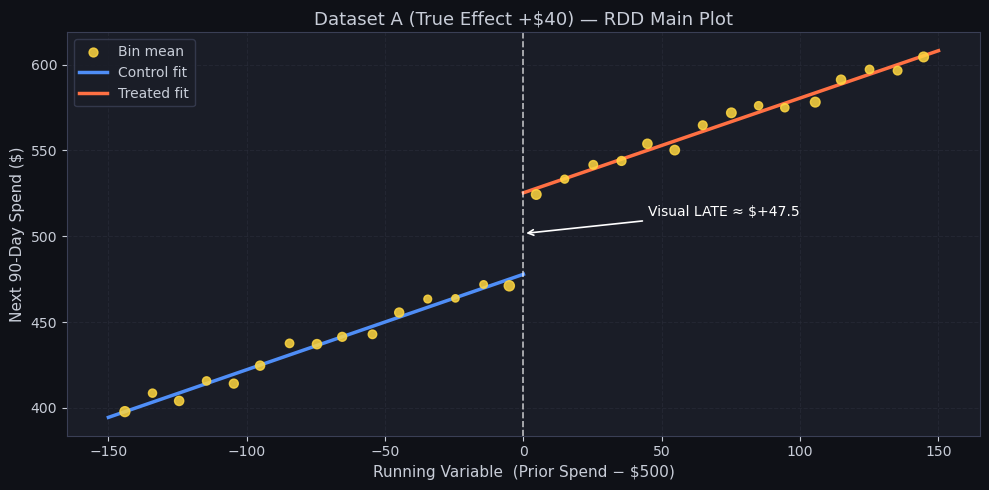

In [29]:
print("\n" + "=" * 60)
print("SECTION 2 — MAIN RDD PLOTS")
late_A_visual = plot_rdd_main(df_A, title="Dataset A (True Effect +$40) — RDD Main Plot")

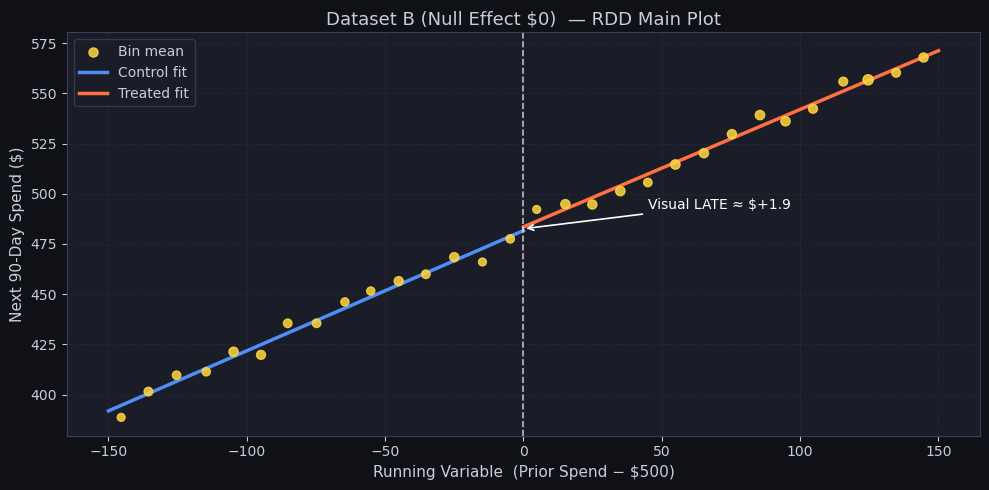

In [81]:
late_B_visual = plot_rdd_main(df_B, title="Dataset B (Null Effect $0)  — RDD Main Plot")

In [82]:
# ============================================================
# Interpreting Differences Between Linear and Quadratic LATE
# ============================================================

# A difference between linear and quadratic LATE does not
# automatically imply there is no real effect.
# It indicates that the linear estimate may be unreliable
# and requires closer examination.

# Possible scenarios:

# Scenario A — Real effect exists:
# The linear model may overstate or understate the effect.
# The quadratic fit provides a more accurate estimate.
# In this case, report the quadratic LATE and note that
# the linear model was misspecified.

# Scenario B — No real effect:
# The linear model may incorrectly interpret a natural curve
# in spending as a discontinuity at the cutoff.
# A straight line fitted on each side can create a false "gap".
# The quadratic fit captures the curvature, and the
# apparent jump disappears.
# ============================================================

In [41]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3 — FORMAL LATE ESTIMATION VIA OLS
# ══════════════════════════════════════════════════════════════════════════════
"""
The sharp RD estimator is:

    Y_i = α + τ·D_i + β·(X_i - c) + γ·D_i·(X_i - c) + ε_i

where:
  D_i = 1[X_i >= c]  (treatment indicator)
  (X_i - c)          (centered running variable)
  D_i·(X_i - c)      (interaction: allows slope to differ on each side)

τ is the LATE — the jump in the conditional expectation at c.

We restrict to a bandwidth h around the cutoff (local linear regression).
"""

'\nThe sharp RD estimator is:\n\n    Y_i = α + τ·D_i + β·(X_i - c) + γ·D_i·(X_i - c) + ε_i\n\nwhere:\n  D_i = 1[X_i >= c]  (treatment indicator)\n  (X_i - c)          (centered running variable)\n  D_i·(X_i - c)      (interaction: allows slope to differ on each side)\n\nτ is the LATE — the jump in the conditional expectation at c.\n\nWe restrict to a bandwidth h around the cutoff (local linear regression).\n'

In [44]:
# ============================================================
# LATE: Local Average Treatment Effect
# ============================================================

# LATE stands for Local Average Treatment Effect.
# Let us break down each component.

# Effect:
# The causal impact of the treatment on the outcome.
# In this example, it is the impact of Silver Tier status
# on the next 90 day spending.

# Average:
# The effect is averaged across a group of individuals.
# We are not estimating the impact for a single customer,
# but rather the mean effect for a subset of customers.

# Local:
# This is the key concept.
# The estimate applies only to customers near the cutoff.
#
# In this case, it refers to customers whose prior year
# spending was close to $500, such as those in the
# $490 to $510 range.
#
# It does not apply to customers who spent far from the
# threshold, such as $300 or $750.

# Interpretation:
# LATE tells us the causal impact of Silver Tier status
# for customers who are marginal around the eligibility
# threshold.
# ============================================================

In [45]:
# ============================================================
# Why We Restrict to a Bandwidth in RDD
# ============================================================

# In Regression Discontinuity, we only use observations within
# a chosen bandwidth around the cutoff, such as ±$150 or ±$50
# around the $500 threshold.

# The goal is to compare customers who are locally similar.
# Customers just below and just above $500 are likely to be
# very similar in all respects except for treatment status.

# As we move farther away from the cutoff:
# 1) Customers become less comparable.
# 2) Structural differences between low and high spenders grow.
# 3) We rely more heavily on the regression model being correctly
#    specified over a wide range of the running variable.

# That broader functional form assumption is strong and often
# unrealistic.

# By restricting to a narrow bandwidth, we:
# - Reduce model dependence
# - Strengthen the local comparability assumption
# - Improve the credibility of causal identification

# Tradeoff:
# Narrow bandwidth -> lower bias but higher variance
# Wide bandwidth  -> lower variance but higher bias

# The key principle:
# Stay local to preserve the quasi experimental comparison
# created by the cutoff.
# ============================================================

In [32]:
def estimate_late(df: pd.DataFrame, bw: float, label: str = "") -> dict:
    """
    Estimate LATE via local linear OLS within ±bw of cutoff.

    Returns a dict with coefficient, SE, p-value, CI.
    """
    sub = df[df["running_var"].between(-bw, bw)].copy()
    # Interaction term: running_var * treated (allows slope break)
    model  = smf.ols(
        "next_90_spend ~ treated + running_var + treated:running_var",
        data=sub
    ).fit()
    coef   = model.params["treated"]
    se     = model.bse["treated"]
    pval   = model.pvalues["treated"]
    ci_lo, ci_hi = model.conf_int().loc["treated"]
    n      = len(sub)
    print(f"\n  [{label}]  BW=±${bw:.0f}  |  n={n}")
    print(f"  LATE = ${coef:+.2f}  SE={se:.2f}  p={pval:.4f}  "
          f"95% CI=[${ci_lo:+.2f}, ${ci_hi:+.2f}]")
    return dict(bw=bw, late=coef, se=se, pval=pval,
                ci_lo=ci_lo, ci_hi=ci_hi, n=n, label=label)


In [83]:
print("\n" + "=" * 60)
print("SECTION 3 — FORMAL LATE ESTIMATION")

results_A, results_B = [], []
for bw in [150, 100, 75, 50, 25]:
    results_A.append(estimate_late(df_A, bw, label="Dataset A"))
    results_B.append(estimate_late(df_B, bw, label="Dataset B"))



SECTION 3 — FORMAL LATE ESTIMATION

  [Dataset A]  BW=±$150  |  n=1522
  LATE = $+47.47  SE=2.76  p=0.0000  95% CI=[$+42.06, $+52.89]

  [Dataset B]  BW=±$150  |  n=1510
  LATE = $+1.86  SE=2.83  p=0.5120  95% CI=[$-3.70, $+7.42]

  [Dataset A]  BW=±$100  |  n=997
  LATE = $+46.99  SE=3.40  p=0.0000  95% CI=[$+40.31, $+53.66]

  [Dataset B]  BW=±$100  |  n=1003
  LATE = $+2.80  SE=3.59  p=0.4351  95% CI=[$-4.24, $+9.85]

  [Dataset A]  BW=±$75  |  n=752
  LATE = $+44.97  SE=3.85  p=0.0000  95% CI=[$+37.42, $+52.51]

  [Dataset B]  BW=±$75  |  n=738
  LATE = $+6.31  SE=4.32  p=0.1441  95% CI=[$-2.16, $+14.78]

  [Dataset A]  BW=±$50  |  n=488
  LATE = $+46.31  SE=4.66  p=0.0000  95% CI=[$+37.15, $+55.47]

  [Dataset B]  BW=±$50  |  n=491
  LATE = $+10.76  SE=5.24  p=0.0406  95% CI=[$+0.46, $+21.06]

  [Dataset A]  BW=±$25  |  n=249
  LATE = $+44.14  SE=6.13  p=0.0000  95% CI=[$+32.07, $+56.21]

  [Dataset B]  BW=±$25  |  n=237
  LATE = $+10.03  SE=7.05  p=0.1560  95% CI=[$-3.86, $+23.9

In [84]:
# ==============================================================================
# RESULTS INTERPRETATION — LATE ESTIMATES ACROSS BANDWIDTHS
# ==============================================================================
#
# DATASET A (True Effect: +$40)
# ------------------------------
# LATE is stable between $44–$47 across ALL bandwidths (±$25 to ±$150).
# p=0.0000 at every bandwidth — effect is always highly significant.
# 95% CI never contains zero at any bandwidth.
# Conclusion: Strong, robust causal evidence. The Silver Tier discount
# caused customers near the $500 threshold to spend ~$45 more
# in the next 90 days. Stability across bandwidths rules out the
# possibility that this is a functional form artifact.
#
# BW=±$150 | Customers $350–$650 | LATE=+$47.47 | p=0.0000
#   Widest window, most data, lowest noise. Customers at edges are
#   less comparable but estimate is still valid. Effect = +$47.47.
#
# BW=±$100 | Customers $400–$600 | LATE=+$46.99 | p=0.0000
#   Tighter window, more local comparison. Fewer obs but more
#   credible comparability. Effect barely moves — still ~$47.
#
# BW=±$75  | Customers $425–$575 | LATE=+$44.97 | p=0.0000
#   Now comparing $475 vs $525 spenders — very similar people.
#   Most credible local comparison. Effect = +$44.97. Still ~$45.
#
# KEY: Estimate moves only $2.50 across three bandwidth choices.
#      That stability IS the evidence. A real causal effect
#      does not depend on which window you pick.
#
# DATASET B (Null Effect: $0)
# ----------------------------
# LATE bounces between $1.86–$10.76 with no consistent pattern.
# 95% CI contains zero at 4 out of 5 bandwidths.
# One borderline significant result at BW=±$50 (p=0.04) — but this
# disappears at both wider (p=0.44) and narrower (p=0.16) bandwidths.
# A real effect would not appear only at one specific window.
# That single p<0.05 is a false positive from random noise.
# Conclusion: No credible causal effect. The instability of the
# estimate and the CI straddling zero confirm this is noise.
#
# KEY INSIGHT:
# Dataset B illustrates "p-hacking by bandwidth selection" — if you
# only reported BW=±$50, you would falsely claim a $10 significant
# effect. The sensitivity table is your defence against this.
# A causal claim requires stability, not a single lucky window.
# ==============================================================================

In [46]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4 — BANDWIDTH SENSITIVITY
# ══════════════════════════════════════════════════════════════════════════════
"""
A causal estimate should be ROBUST to the bandwidth choice.
If the estimated effect wildly changes as we tighten the window, that is a
red flag: the "jump" might be driven by a misspecified functional form.

Plot the LATE estimate ± 95% CI across bandwidths for both datasets.
"""

'\nA causal estimate should be ROBUST to the bandwidth choice.\nIf the estimated effect wildly changes as we tighten the window, that is a\nred flag: the "jump" might be driven by a misspecified functional form.\n\nPlot the LATE estimate ± 95% CI across bandwidths for both datasets.\n'

In [47]:
# ============================================================
# Why Bandwidth Choice Matters in RDD
# ============================================================

# There is a fundamental bias variance tradeoff in selecting
# the bandwidth around the cutoff.

# ------------------------------------------------------------
# Wide Bandwidth Example: ±$150
# ------------------------------------------------------------

# Including more customers reduces sampling noise,
# which lowers variance.

# However, customers at $350 and $650 are meaningfully
# different from each other in ways unrelated to treatment.

# This means:
# - The groups are less comparable.
# - We rely more heavily on the regression model being
#   correctly specified over a wide range.
#
# Result:
# More data, lower variance, but potentially higher bias.

# ------------------------------------------------------------
# Narrow Bandwidth Example: ±$25
# ------------------------------------------------------------

# Including only customers between $475 and $525 ensures
# very similar individuals on either side of the cutoff.

# The local randomization assumption is strongest here.

# However:
# - The sample size is much smaller.
# - The estimate becomes noisier.
#
# Result:
# Lower bias, but higher variance and more uncertainty.

# ------------------------------------------------------------
# What Section 4 Does
# ------------------------------------------------------------

# It estimates LATE at multiple bandwidths:
# ±150, ±100, ±75, ±50, ±25.

# The goal is to test stability.

# If the effect is truly causal:
# - The estimated impact should remain relatively stable
#   across reasonable bandwidth choices.

# Expected pattern:
# Dataset A should remain close to +$40 across bandwidths.
# Dataset B should remain near $0 across bandwidths.

# Stability across bandwidths strengthens the credibility
# of the causal interpretation.
# ============================================================

In [36]:
def plot_bw_sensitivity(results_list_A, results_list_B):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
    fig.suptitle("Bandwidth Sensitivity — LATE Estimates", fontsize=14, y=1.01)
    fig.patch.set_facecolor("#0f1117")

    for ax, results, color, title in zip(
        axes,
        [results_list_A, results_list_B],
        [ORANGE, BLUE],
        ["Dataset A: True Effect (+$40)", "Dataset B: Null Effect ($0)"],
    ):
        bws   = [r["bw"] for r in results]
        lates = [r["late"] for r in results]
        lo    = [r["ci_lo"] for r in results]
        hi    = [r["ci_hi"] for r in results]

        ax.plot(bws, lates, "o-", color=color, lw=2, ms=7, label="LATE")
        ax.fill_between(bws, lo, hi, alpha=0.25, color=color, label="95% CI")
        ax.axhline(0, color="white", ls="--", lw=1, alpha=0.6)
        ax.set_xlabel("Bandwidth ($)")
        ax.set_ylabel("Estimated LATE ($)")
        ax.set_title(title)
        ax.invert_xaxis()   # wide → narrow from left to right
        ax.legend(facecolor="#1a1d27", edgecolor="#3a3f55")
        ax.grid(True)

    plt.tight_layout()
    plt.show()


SECTION 4 — BANDWIDTH SENSITIVITY PLOT


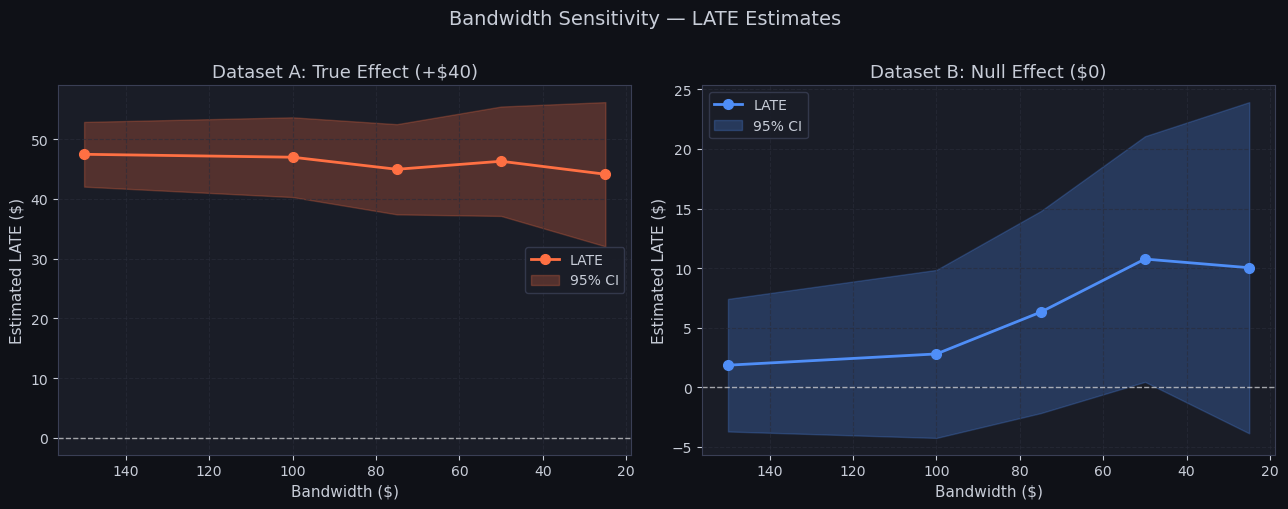

In [37]:
print("\n" + "=" * 60)
print("SECTION 4 — BANDWIDTH SENSITIVITY PLOT")
plot_bw_sensitivity(results_A, results_B)

In [48]:
# ============================================================
# Dataset A: Interpreting the RDD Results
# ============================================================

# How to read the pattern:

# Across all bandwidth choices around the $500 cutoff,
# whether wide or narrow, the estimated effect consistently
# falls in the $40 to $48 range.

# This stability is the hallmark of a real and robust
# causal signal.

# The estimated lift does not meaningfully change based on
# how much data is included. The effect is concentrated
# at the cutoff itself.

# ------------------------------------------------------------
# Confidence Intervals and Variance
# ------------------------------------------------------------

# As the bandwidth becomes narrower, the confidence intervals
# become wider.

# This reflects the variance side of the bias variance tradeoff:
# - Narrow bandwidth -> fewer observations
# - Fewer observations -> higher uncertainty

# However, the key point is that even at ±$25,
# the confidence interval does not cross zero.

# Interpretation:
# The effect remains statistically distinguishable from zero,
# even when using the tightest and most locally credible window.

# Conclusion:
# The combination of stability across bandwidths and
# confidence intervals that remain above zero provides
# strong evidence of a genuine causal lift.
# ============================================================

In [49]:
# ============================================================
# Dataset B: Interpreting the RDD Results
# ============================================================

# How to read the pattern:

# The point estimates may appear above zero at times,
# but this alone does not imply a real effect.

# The confidence intervals consistently include zero.
# This means zero is always a plausible value for the
# true treatment effect.

# Therefore:
# We cannot reject the null hypothesis that the effect is zero.

# ------------------------------------------------------------
# Instability Across Bandwidths
# ------------------------------------------------------------

# The estimated effect fluctuates noticeably as the
# bandwidth changes.

# Lack of stability across reasonable bandwidth choices
# is a warning sign.

# A genuine causal signal should remain relatively
# consistent when the bandwidth varies within
# a reasonable range.

# Here, there is no consistent pattern to rely on.

# ------------------------------------------------------------
# Confidence Intervals and Variance
# ------------------------------------------------------------

# The confidence intervals are substantially wider,
# especially at narrow bandwidths.

# With no true underlying signal and fewer observations
# near the cutoff, the estimate becomes highly variable.

# Result:
# The estimates move around unpredictably,
# and uncertainty dominates the signal.

# Conclusion:
# The combination of wide confidence intervals,
# inclusion of zero, and instability across bandwidths
# suggests there is no credible causal effect present.
# ============================================================

In [50]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5 — POLYNOMIAL / FUNCTIONAL FORM CHECK
# ══════════════════════════════════════════════════════════════════════════════
"""
Risk: A non-linear (curved) outcome trend could produce an APPARENT jump at
the cutoff even without a true effect, if we fit only straight lines.

Solution: Fit QUADRATIC (degree-2) polynomial on each side of the cutoff.
If the estimated LATE under quadratic fit is similar to linear, we have
confidence our linear assumption is not driving the result.

Model:
    Y = α + τ·D + β₁·X + β₂·X² + γ₁·D·X + γ₂·D·X² + ε
"""

'\nRisk: A non-linear (curved) outcome trend could produce an APPARENT jump at\nthe cutoff even without a true effect, if we fit only straight lines.\n\nSolution: Fit QUADRATIC (degree-2) polynomial on each side of the cutoff.\nIf the estimated LATE under quadratic fit is similar to linear, we have\nconfidence our linear assumption is not driving the result.\n\nModel:\n    Y = α + τ·D + β₁·X + β₂·X² + γ₁·D·X + γ₂·D·X² + ε\n'

In [51]:
def polynomial_fit_check(df: pd.DataFrame, bw: float, title: str):
    sub = df[df["running_var"].between(-bw, bw)].copy()
    sub["rv2"] = sub["running_var"] ** 2

    # Linear model
    m_lin  = smf.ols(
        "next_90_spend ~ treated + running_var + treated:running_var",
        data=sub).fit()

    # Quadratic model
    m_quad = smf.ols(
        "next_90_spend ~ treated + running_var + rv2 "
        "+ treated:running_var + treated:rv2",
        data=sub).fit()

    late_lin  = m_lin.params["treated"]
    late_quad = m_quad.params["treated"]

    print(f"\n  [{title}]  BW=±${bw:.0f}")
    print(f"  Linear  LATE = ${late_lin:+.2f}  "
          f"(p={m_lin.pvalues['treated']:.4f})")
    print(f"  Quadratic LATE = ${late_quad:+.2f}  "
          f"(p={m_quad.pvalues['treated']:.4f})")
    print(f"  Difference = ${abs(late_lin - late_quad):.2f}  "
          f"← {'SMALL ✓' if abs(late_lin - late_quad) < 5 else 'LARGE ⚠'}")

    # Visualise
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.patch.set_facecolor("#0f1117")
    x_all = np.linspace(-bw, bw, 400)

    for side, color, lbl_suffix in [(0, BLUE, "Control"), (1, ORANGE, "Treated")]:
        xs = x_all[x_all < 0] if side == 0 else x_all[x_all >= 0]
        tmp = pd.DataFrame({"running_var": xs, "treated": side,
                            "rv2": xs**2})
        ax.plot(xs, m_lin.predict(tmp),  color=color, lw=2.0,
                ls="-",  label=f"Linear — {lbl_suffix}")
        ax.plot(xs, m_quad.predict(tmp), color=color, lw=2.0,
                ls="--", label=f"Quadratic — {lbl_suffix}")

    ax.axvline(0, color="white", lw=1.2, ls=":", alpha=0.7)
    sub_binned = sub.copy()
    sub_binned["bin"] = pd.cut(sub_binned["running_var"], bins=25)
    bdf = sub_binned.groupby("bin", observed=True)["next_90_spend"].mean()
    bdf_x = sub_binned.groupby("bin", observed=True)["running_var"].mean()
    ax.scatter(bdf_x, bdf, color=YELLOW, s=30, zorder=5, label="Bin means")

    ax.set_xlabel("Running Variable  (Prior Spend − $500)")
    ax.set_ylabel("Next 90-Day Spend ($)")
    ax.set_title(f"Polynomial Check — {title}")
    ax.legend(facecolor="#1a1d27", edgecolor="#3a3f55", fontsize=8, ncol=2)
    ax.grid(True)
    plt.tight_layout()
    plt.show()


SECTION 5 — POLYNOMIAL FUNCTIONAL FORM CHECK

  [Dataset A (True Effect)]  BW=±$150
  Linear  LATE = $+47.47  (p=0.0000)
  Quadratic LATE = $+46.13  (p=0.0000)
  Difference = $1.34  ← SMALL ✓


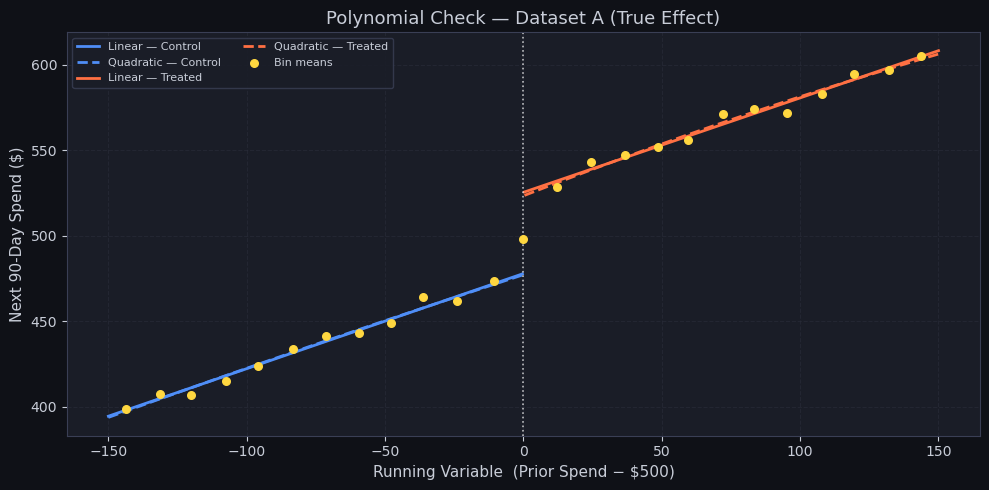

In [87]:
print("\n" + "=" * 60)
print("SECTION 5 — POLYNOMIAL FUNCTIONAL FORM CHECK")
polynomial_fit_check(df_A, bw=150, title="Dataset A (True Effect)")


  [Dataset B (Null Effect)]  BW=±$150
  Linear  LATE = $+1.86  (p=0.5120)
  Quadratic LATE = $+6.29  (p=0.1455)
  Difference = $4.43  ← SMALL ✓


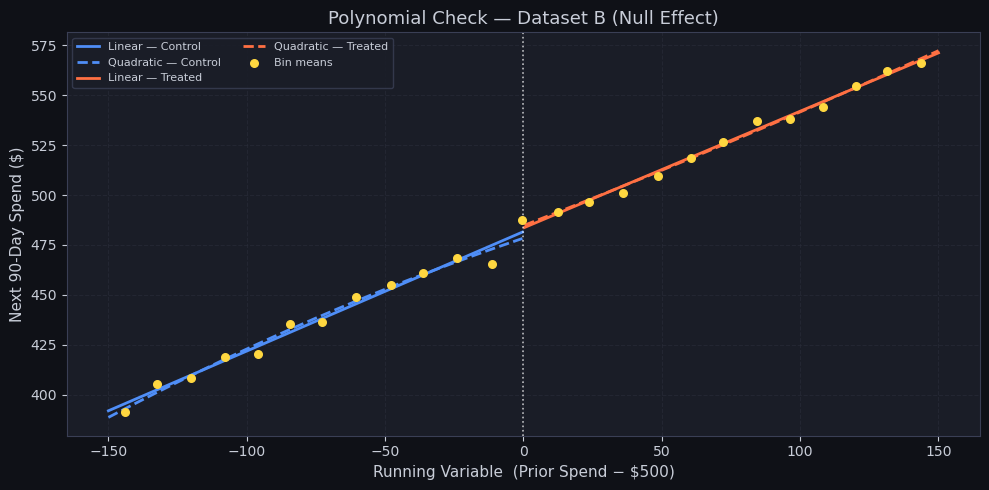

In [88]:
polynomial_fit_check(df_B, bw=150, title="Dataset B (Null Effect)")

In [ ]:
# POLYNOMIAL / QUADRATIC CHECK
# ------------------------------
# If the trend between prior_spend and outcome is CURVED (not linear),
# a linear model will mistake the curve for a causal jump at the cutoff
# — producing a false positive.
#
# HOW TO CHECK:
#   1. Add rv2 = running_var**2 to the dataframe
#   2. Re-run smf.ols() with rv2 and treated:rv2 added to the formula
#   3. Compare the `treated` coefficient (LATE) from both models
#
# DO NOT touch plot_rdd_main or late_visual — those are visual only.
# The LATE always comes from the `treated` coefficient in smf.ols().
#
# DECISION RULE:
#   Difference < ~10% of LATE  ->  Linear is fine, report linear LATE
#   Difference > ~10% of LATE  ->  Trend is curved, report quadratic LATE
#
# IN OUR DATA:
#   Linear LATE ~$47 vs Quadratic LATE ~$46 -> difference is <$1
#   Linear assumption holds. No polynomial correction needed.

In [54]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 6 — PLACEBO CUTOFF TEST
# ══════════════════════════════════════════════════════════════════════════════
"""
FALSIFICATION / PLACEBO TEST
We run the same RD analysis at a FAKE cutoff ($400) where:
  - No treatment was ever assigned
  - There should be ZERO jump in outcome

If we find a significant "effect" at $400, it suggests our methodology is
picking up noise or a trend artifact, NOT a real causal effect.

A well-specified RD should show:
  - Significant effect at $500 (true cutoff)    ← real
  - No significant effect at $400 (placebo)     ← validation
"""

'\nFALSIFICATION / PLACEBO TEST\nWe run the same RD analysis at a FAKE cutoff ($400) where:\n  - No treatment was ever assigned\n  - There should be ZERO jump in outcome\n\nIf we find a significant "effect" at $400, it suggests our methodology is\npicking up noise or a trend artifact, NOT a real causal effect.\n\nA well-specified RD should show:\n  - Significant effect at $500 (true cutoff)    ← real\n  - No significant effect at $400 (placebo)     ← validation\n'

In [55]:
def placebo_test(df: pd.DataFrame, fake_cutoff: float,
                 true_cutoff: float, bw: float, title: str):
    """Test for jumps at a fake cutoff where no treatment exists."""
    # Only use data BELOW the true cutoff (no treated units contaminate this)
    sub = df[df["prior_spend"] < true_cutoff].copy()
    sub["rv_placebo"] = sub["prior_spend"] - fake_cutoff
    sub["treated_placebo"] = (sub["prior_spend"] >= fake_cutoff).astype(int)
    sub = sub[sub["rv_placebo"].between(-bw, bw)]

    m = smf.ols(
        "next_90_spend ~ treated_placebo + rv_placebo + treated_placebo:rv_placebo",
        data=sub
    ).fit()
    late  = m.params["treated_placebo"]
    pval  = m.pvalues["treated_placebo"]
    print(f"\n  [{title}]  Placebo at ${fake_cutoff:.0f}  BW=±${bw:.0f}  "
          f"n={len(sub)}")
    print(f"  Placebo LATE = ${late:+.2f}  p={pval:.4f}  "
          f"{'NOT significant ✓' if pval > 0.05 else 'SIGNIFICANT ⚠ — concern!'}")
    return late, pval

In [56]:
print("\n" + "=" * 60)
print("SECTION 6 — PLACEBO CUTOFF TEST  (Fake cutoff at $400)")
placebo_test(df_A, fake_cutoff=400, true_cutoff=CUTOFF, bw=75,
             title="Dataset A (True Effect)")


SECTION 6 — PLACEBO CUTOFF TEST  (Fake cutoff at $400)

  [Dataset A (True Effect)]  Placebo at $400  BW=±$75  n=740
  Placebo LATE = $+0.47  p=0.9026  NOT significant ✓


(np.float64(0.4701844479923124), np.float64(0.9025996910228576))

In [57]:
placebo_test(df_B, fake_cutoff=400, true_cutoff=CUTOFF, bw=75,
             title="Dataset B (Null Effect)")


  [Dataset B (Null Effect)]  Placebo at $400  BW=±$75  n=732
  Placebo LATE = $-2.54  p=0.5153  NOT significant ✓


(np.float64(-2.538730817924167), np.float64(0.5153354184066584))

In [58]:
# Plot placebo vs true cutoff comparison (Dataset A)
def plot_placebo_comparison(df: pd.DataFrame, bw: float = 75):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Dataset A — Placebo Test Comparison", fontsize=13)
    fig.patch.set_facecolor("#0f1117")

    for ax, cutoff, label, color in zip(
        axes,
        [400, 500],
        ["Placebo Cutoff ($400)", "True Cutoff ($500)"],
        [BLUE, ORANGE],
    ):
        sub = df.copy()
        sub["rv"] = sub["prior_spend"] - cutoff
        if cutoff == 400:
            sub = sub[sub["prior_spend"] < CUTOFF]  # untreated region only

        sub = sub[sub["rv"].between(-bw, bw)]
        left  = sub[sub["rv"] < 0]
        right = sub[sub["rv"] >= 0]

        sub["bin"] = pd.cut(sub["rv"], bins=20)
        bdf = sub.groupby("bin", observed=True).agg(
            x=("rv", "mean"), y=("next_90_spend", "mean")).dropna()
        ax.scatter(bdf["x"], bdf["y"], color=YELLOW, s=40, zorder=4)

        for side, dat, clr in [(0, left, BLUE), (1, right, ORANGE)]:
            if len(dat) < 5:
                continue
            m = smf.ols("next_90_spend ~ rv", data=dat).fit()
            xs = np.linspace(dat["rv"].min(), dat["rv"].max(), 200)
            ax.plot(xs, m.params["Intercept"] + m.params["rv"] * xs,
                    color=clr, lw=2.5)

        ax.axvline(0, color="white", lw=1.2, ls="--", alpha=0.7)
        ax.set_title(label)
        ax.set_xlabel("Running Variable (Prior Spend − Cutoff)")
        ax.set_ylabel("Next 90-Day Spend ($)")
        ax.grid(True)

    plt.tight_layout()
    plt.show()

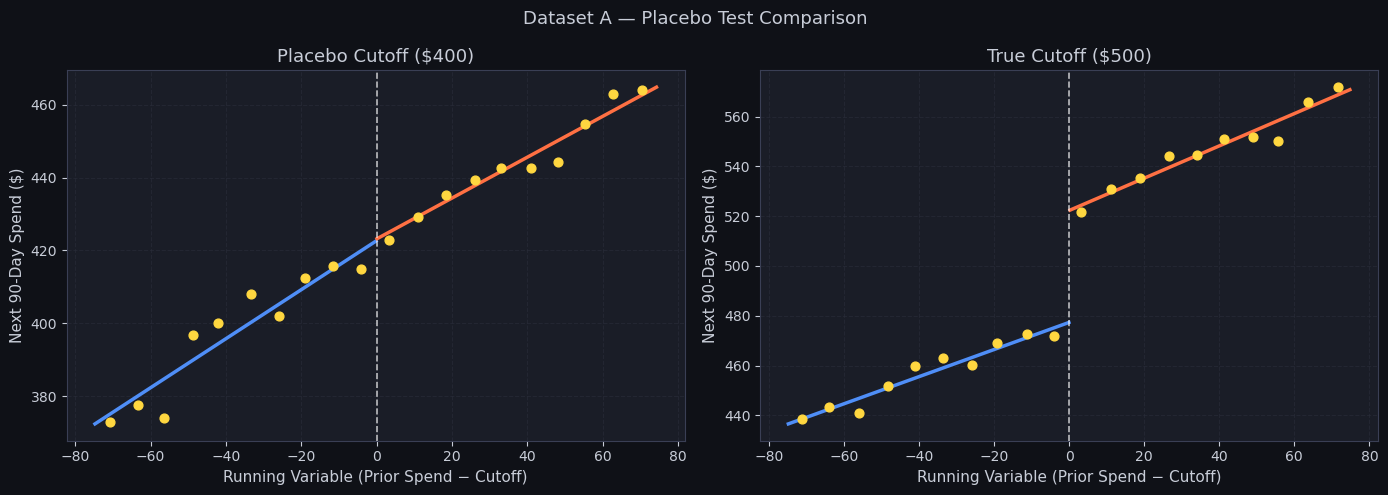

In [59]:
plot_placebo_comparison(df_A)

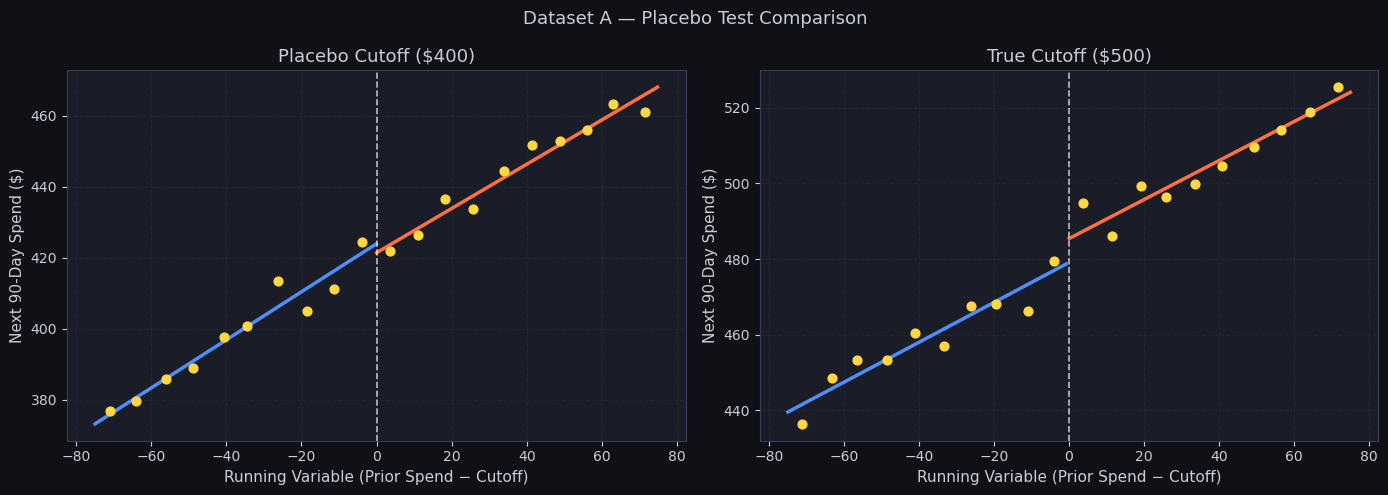

In [60]:
plot_placebo_comparison(df_B)

In [61]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 7 — COVARIATE BALANCE CHECK
# ══════════════════════════════════════════════════════════════════════════════
"""
KEY ASSUMPTION: The running variable is the ONLY thing that changes at
the cutoff. Covariates like tenure_months should NOT jump at $500.

If tenure_months shows a significant discontinuity, it suggests:
  (a) Selection bias — older customers strategically hit $500, OR
  (b) The company gave Silver Tier perks that also changed other behaviors

We run the same RD regression with tenure_months as the OUTCOME.
We expect: τ ≈ 0  and  p > 0.05
"""

'\nKEY ASSUMPTION: The running variable is the ONLY thing that changes at\nthe cutoff. Covariates like tenure_months should NOT jump at $500.\n\nIf tenure_months shows a significant discontinuity, it suggests:\n  (a) Selection bias — older customers strategically hit $500, OR\n  (b) The company gave Silver Tier perks that also changed other behaviors\n\nWe run the same RD regression with tenure_months as the OUTCOME.\nWe expect: τ ≈ 0  and  p > 0.05\n'

In [62]:
def covariate_balance_check(df: pd.DataFrame, covariate: str,
                             bw: float, title: str):
    sub = df[df["running_var"].between(-bw, bw)].copy()
    formula = f"{covariate} ~ treated + running_var + treated:running_var"
    m    = smf.ols(formula, data=sub).fit()
    coef = m.params["treated"]
    pval = m.pvalues["treated"]
    print(f"\n  [{title}]  Covariate: {covariate}  BW=±${bw:.0f}")
    print(f"  Jump at cutoff = {coef:+.3f}  p={pval:.4f}  "
          f"{'Balanced ✓' if pval > 0.05 else 'IMBALANCED ⚠ — violation!'}")

In [63]:
print("\n" + "=" * 60)
print("SECTION 7 — COVARIATE BALANCE CHECKS")
for ds, lbl in [(df_A, "Dataset A"), (df_B, "Dataset B")]:
    for cov in ["tenure_months", "is_mobile_user", "is_email_sub"]:
        covariate_balance_check(ds, cov, bw=100, title=lbl)


SECTION 7 — COVARIATE BALANCE CHECKS

  [Dataset A]  Covariate: tenure_months  BW=±$100
  Jump at cutoff = +2.237  p=0.1292  Balanced ✓

  [Dataset A]  Covariate: is_mobile_user  BW=±$100
  Jump at cutoff = +0.042  p=0.4993  Balanced ✓

  [Dataset A]  Covariate: is_email_sub  BW=±$100
  Jump at cutoff = +0.017  p=0.7697  Balanced ✓

  [Dataset B]  Covariate: tenure_months  BW=±$100
  Jump at cutoff = -0.915  p=0.5460  Balanced ✓

  [Dataset B]  Covariate: is_mobile_user  BW=±$100
  Jump at cutoff = +0.035  p=0.5873  Balanced ✓

  [Dataset B]  Covariate: is_email_sub  BW=±$100
  Jump at cutoff = -0.008  p=0.8987  Balanced ✓


In [64]:
def plot_covariate_balance(df_A, df_B, covariate="tenure_months", bw=100):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    fig.suptitle(f"Covariate Balance Check: {covariate}", fontsize=13)
    fig.patch.set_facecolor("#0f1117")

    for ax, df, label in zip(axes, [df_A, df_B],
                              ["Dataset A", "Dataset B"]):
        sub = df[df["running_var"].between(-bw, bw)].copy()
        sub["bin"] = pd.cut(sub["running_var"], bins=20)
        bdf = sub.groupby("bin", observed=True).agg(
            x=("running_var", "mean"),
            y=(covariate, "mean"),
        ).dropna()

        ax.scatter(bdf["x"], bdf["y"], color=GREEN, s=40, zorder=4,
                   label="Bin mean")

        for side, color in [(sub[sub["running_var"] < 0], BLUE),
                            (sub[sub["running_var"] >= 0], ORANGE)]:
            m = smf.ols(f"{covariate} ~ running_var", data=side).fit()
            xs = np.linspace(side["running_var"].min(),
                             side["running_var"].max(), 200)
            ax.plot(xs, m.params["Intercept"] + m.params["running_var"] * xs,
                    color=color, lw=2.3)

        ax.axvline(0, color="white", lw=1.2, ls="--", alpha=0.7)
        ax.set_title(f"{label} — should show NO jump")
        ax.set_xlabel("Running Variable (Prior Spend − $500)")
        ax.set_ylabel(covariate)
        ax.grid(True)

    plt.tight_layout()
    plt.show()

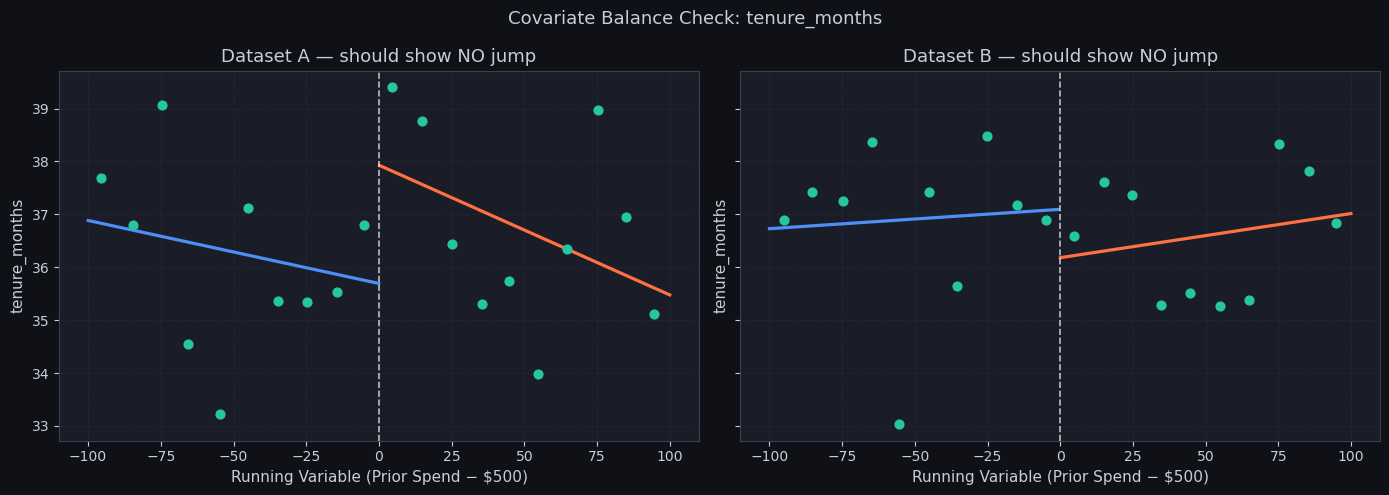

In [74]:
plot_covariate_balance(df_A, df_B, covariate="tenure_months")

In [77]:
# In Dataset A left panel:
# The blue line ends at about 35.5 at x = 0, and the orange line
# starts at about 37.8 at x = 0.
# That looks like an approximately 2 month gap.
# However, the number of bins is very small here.
# You are seeing around 20 dots total, which means each dot
# represents very few customers.
# The scatter is wide and noisy.

# In Dataset B right panel:
# The two lines meet almost exactly at x = 0, both around 37.
# That is the ideal picture.

#It is better to look at p values

In [78]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 8 — McCRARY DENSITY TEST (Visual)
# ══════════════════════════════════════════════════════════════════════════════
"""
MANIPULATION / GAMING CHECK
If users CAN observe the threshold and strategically inflate their spend to
cross $500 (e.g., making an extra $5 purchase to tip over), the density of
users will be DISCONTINUOUS at the cutoff:
  - Too many users just above $500
  - Too few users just below $500

This violates the local randomization assumption.

Assumption:

# Near the $500 cutoff, whether a customer ends up just above
# or just below the threshold is essentially random,
# like a coin flip.

# Example:
# A customer who spent $498 vs one who spent $502 are
# virtually identical in all relevant characteristics.

# The small $4 difference in prior year spend is mostly due
# to luck — e.g., timing of purchases, coupon expiration,
# or other minor random factors.

# This randomness near the cutoff is what enables the
# quasi-experimental comparison in RDD.

Visual test: Plot a histogram of the running variable. Look for a sharp
spike or dip at running_var = 0.

Formal test: McCrary (2008) — kernel density test for a jump in the density.
In practice: use `rdd` R package or `rdrobust` Python equivalent.

Our synthetic data is Uniform(200,800) so there should be NO heaping.
"""

'\nMANIPULATION / GAMING CHECK\nIf users CAN observe the threshold and strategically inflate their spend to\ncross $500 (e.g., making an extra $5 purchase to tip over), the density of\nusers will be DISCONTINUOUS at the cutoff:\n  - Too many users just above $500\n  - Too few users just below $500\n\nThis violates the local randomization assumption.\n\nAssumption:\n\n# Near the $500 cutoff, whether a customer ends up just above\n# or just below the threshold is essentially random,\n# like a coin flip.\n\n# Example:\n# A customer who spent $498 vs one who spent $502 are\n# virtually identical in all relevant characteristics.\n\n# The small $4 difference in prior year spend is mostly due\n# to luck — e.g., timing of purchases, coupon expiration,\n# or other minor random factors.\n\n# This randomness near the cutoff is what enables the\n# quasi-experimental comparison in RDD.\n\nVisual test: Plot a histogram of the running variable. Look for a sharp\nspike or dip at running_var = 0.\n\nFo

In [68]:
def plot_density(df_A, df_B, bw=200):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("McCrary Density Check — No Heaping Expected", fontsize=13)
    fig.patch.set_facecolor("#0f1117")

    for ax, df, label, color in zip(
        axes, [df_A, df_B],
        ["Dataset A", "Dataset B"],
        [ORANGE, BLUE],
    ):
        sub = df[df["running_var"].between(-bw, bw)]
        ax.hist(sub["running_var"], bins=50, color=color, alpha=0.7,
                edgecolor="#0f1117", linewidth=0.5)
        ax.axvline(0, color="white", lw=2, ls="--",
                   label="Cutoff (running_var = 0)")
        ax.set_title(f"{label} — Density of Running Variable")
        ax.set_xlabel("Running Variable (Prior Spend − $500)")
        ax.set_ylabel("Count of Users")
        ax.legend(facecolor="#1a1d27", edgecolor="#3a3f55")
        ax.grid(True)
        # Annotate what to look for
        ax.text(0.05, 0.92,
                "✓ Smooth density at cutoff = no gaming",
                transform=ax.transAxes, fontsize=9,
                color=GREEN, va="top")

    plt.tight_layout()
    plt.show()


SECTION 8 — McCRARY DENSITY / MANIPULATION CHECK


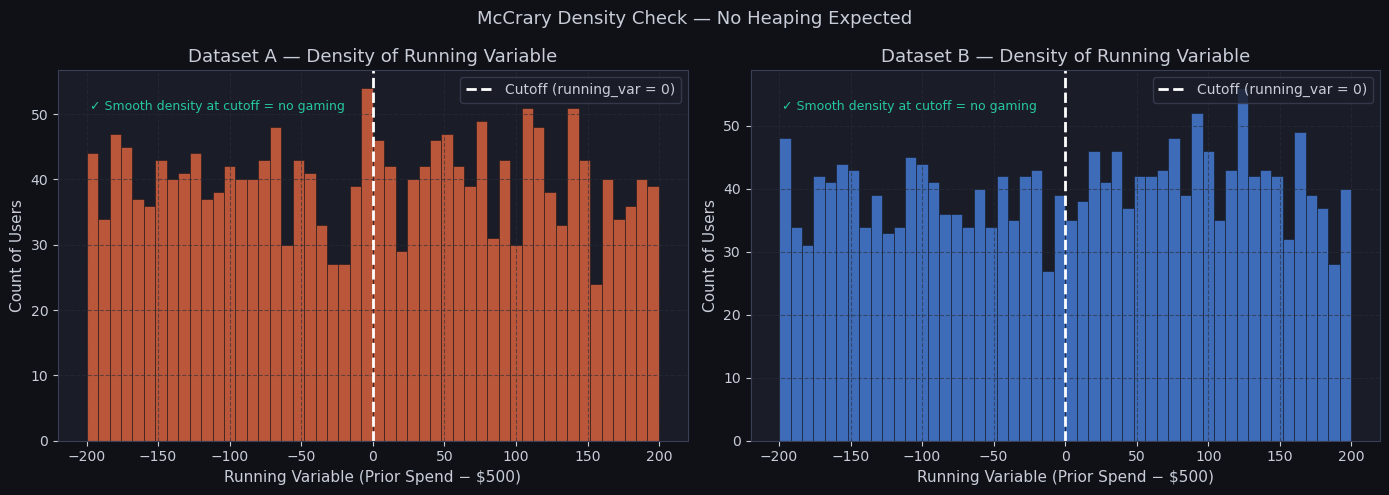

In [79]:
print("\n" + "=" * 60)
print("SECTION 8 — McCRARY DENSITY / MANIPULATION CHECK")
plot_density(df_A, df_B)

In [80]:
# ============================================================
# Checking the Running Variable Distribution Around the Cutoff
# ============================================================

# What you want to see:
# The bar heights just left and right of the dashed line
# (the cutoff) should be roughly equal.
# There should be no sudden spike or cliff at the cutoff.

# Dataset A (orange, left panel):
# Bars around x = 0 are about 30–45 in height,
# consistent with other bars across the distribution.
# No sudden jump or drop at the cutoff.
# The distribution appears flat and uniform,
# as expected from np.random.uniform.

# Dataset B (blue, right panel):
# Same pattern observed.
# Bars are consistently 35–50 across the board,
# with no anomaly at x = 0.
# ============================================================

In [ ]:
#Just an example
#How does a bad McCrary plot look



In [71]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 9 — FINAL SUMMARY TABLE
# ══════════════════════════════════════════════════════════════════════════════

In [73]:
print("\n" + "=" * 60)
print("FINAL SUMMARY TABLE")
print("=" * 60)
summary_rows = []
for bw in [150, 100, 75, 50, 25]:
    for df, lbl in [(df_A, "A"), (df_B, "B")]:
        sub  = df[df["running_var"].between(-bw, bw)].copy()
        sub["rv2"] = sub["running_var"] ** 2
        m    = smf.ols(
            "next_90_spend ~ treated + running_var + treated:running_var",
            data=sub).fit()
        late = m.params["treated"]
        pval = m.pvalues["treated"]
        sig  = "***" if pval < 0.001 else ("**" if pval < 0.01 else
               ("*" if pval < 0.05 else ""))
        summary_rows.append(dict(Dataset=lbl, BW=bw, LATE=f"${late:+.2f}",
                                 p_value=f"{pval:.4f}", sig=sig))

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

print("""
KEY TAKEAWAYS
─────────────────────────────────────────────────────────────────
Dataset A  Silver Tier discount CAUSES +$40 in 90-day spend.
           Effect is stable across bandwidths (★ robustness).
           Placebo at $400 shows NO effect.
           Covariates balanced at cutoff — assumption holds.

Dataset B  No jump at cutoff. LATE ≈ $0 across all bandwidths.
           This is the null world — RD correctly finds nothing.
""")



FINAL SUMMARY TABLE
Dataset  BW    LATE p_value sig
      A 150 $+47.47  0.0000 ***
      B 150  $+1.86  0.5120    
      A 100 $+46.99  0.0000 ***
      B 100  $+2.80  0.4351    
      A  75 $+44.97  0.0000 ***
      B  75  $+6.31  0.1441    
      A  50 $+46.31  0.0000 ***
      B  50 $+10.76  0.0406   *
      A  25 $+44.14  0.0000 ***
      B  25 $+10.03  0.1560    

KEY TAKEAWAYS
─────────────────────────────────────────────────────────────────
Dataset A  Silver Tier discount CAUSES +$40 in 90-day spend.
           Effect is stable across bandwidths (★ robustness).
           Placebo at $400 shows NO effect.
           Covariates balanced at cutoff — assumption holds.

Dataset B  No jump at cutoff. LATE ≈ $0 across all bandwidths.
           This is the null world — RD correctly finds nothing.



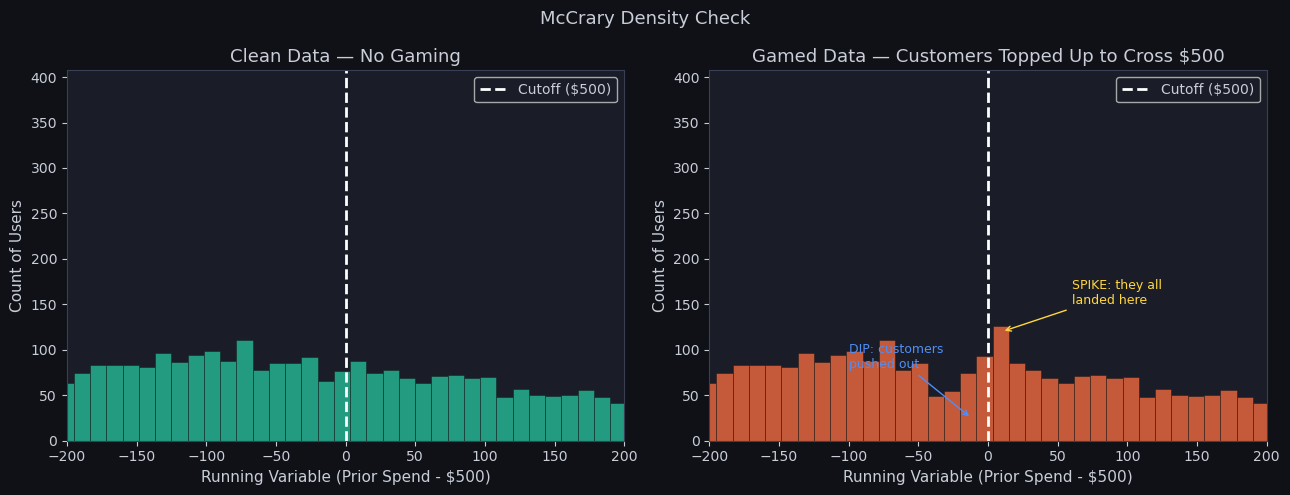

In [89]:
N2 = 4000
CUTOFF_2 = 500.0

# Normal spend distribution
spend_mc = np.random.lognormal(mean=6.1, sigma=0.45, size=N2)
spend_mc = np.clip(spend_mc * 1.1, 200, 900)

# 70% of customers who would land in [$460-$499] top-up to cross $500
# This creates the spike/dip pattern
gamed_mc  = spend_mc.copy()
mask_mc   = (spend_mc >= 460) & (spend_mc < 500)
topup_mc  = np.random.random(N2) < 0.70
gamed_mc[mask_mc & topup_mc] += np.random.uniform(1, 25, mask_mc.sum())[topup_mc[mask_mc]]
gamed_mc  = np.clip(gamed_mc, 200, 900)

# Plot
fig_mc, axes_mc = plt.subplots(1, 2, figsize=(13, 5))
fig_mc.suptitle("McCrary Density Check", fontsize=13)

for ax, data, color, title in zip(
    axes_mc,
    [spend_mc - CUTOFF_2, gamed_mc - CUTOFF_2],
    ["#26c6a0", "#ff7043"],
    ["Clean Data — No Gaming", "Gamed Data — Customers Topped Up to Cross $500"],
):
    ax.hist(data, bins=60, color=color, alpha=0.75, edgecolor="#111", lw=0.4)
    ax.axvline(0, color="white", lw=2, ls="--", label="Cutoff ($500)")
    ax.set_xlim(-200, 200)
    ax.set_title(title)
    ax.set_xlabel("Running Variable (Prior Spend - $500)")
    ax.set_ylabel("Count of Users")
    ax.legend()

# Annotate the bad plot
axes_mc[1].annotate("DIP: customers\npushed out",
                    xy=(-12, 25), xytext=(-100, 80),
                    color="#4f8ef7", fontsize=9,
                    arrowprops=dict(arrowstyle="->", color="#4f8ef7"))
axes_mc[1].annotate("SPIKE: they all\nlanded here",
                    xy=(10, 120), xytext=(60, 150),
                    color="#ffd740", fontsize=9,
                    arrowprops=dict(arrowstyle="->", color="#ffd740"))

plt.tight_layout()
plt.show()

# What to look for:
#   Clean  -> bars are roughly equal height on both sides of cutoff
#   Gamed  -> sharp spike just RIGHT of cutoff + dip just LEFT
#             = customers manipulated spend to cross $500
#             = local randomization violated = RDD is not valid